In [7]:
from langgraph.graph import START,END, StateGraph
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv


In [8]:
load_dotenv()

True

In [9]:
model=ChatGroq(model="llama-3.3-70b-versatile")

In [10]:
class BlogState(TypedDict):
    outline:str
    blog:str
    topic:str


In [22]:
def generate_outline(state:BlogState) ->BlogState:
    topic=state['topic']
    prompt=f"Generate a one line outline for this topic- {topic}"
    res=model.invoke(prompt)
    state['outline']=res.content
    return state

def generate_blog(state:BlogState)->BlogState:
    outline=state['outline']
    prompt=f"Generate a blog on this outline- {outline}"
    res=model.invoke(prompt)
    state['blog']=res.content
    return state



In [23]:
state=StateGraph(BlogState)

state.add_node("generate_outline",generate_outline)
state.add_node("generate_blog",generate_blog)

state.add_edge(START,"generate_outline")
state.add_edge("generate_outline","generate_blog")
state.add_edge("generate_blog",END)
workflow=state.compile()


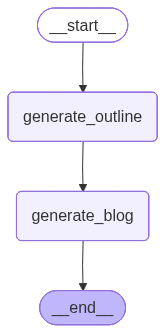

In [24]:
workflow

In [25]:
initial_state={"topic":"India"}
workflow.invoke(initial_state)

{'outline': 'The topic of India can be outlined as: I. Introduction to India, covering its history, culture, geography, economy, and politics, to provide a comprehensive understanding of the country.',
 'blog': "**Introduction to India: A Comprehensive Overview**\n\nIndia, a country located in South Asia, is a land of rich history, diverse culture, and stunning natural beauty. With a population of over 1.3 billion people, India is the second-most populous country in the world and is considered one of the fastest-growing major economies. In this blog, we will delve into the various aspects of India, covering its history, culture, geography, economy, and politics, to provide a comprehensive understanding of this fascinating country.\n\n**History of India**\n\nIndia's history dates back to the Indus Valley Civilization, which existed over 4,000 years ago. The country has been ruled by various empires and dynasties, including the Mauryan, Gupta, and Mughal empires. The British East India C